In [1]:
import os
import sys
import warnings

import matplotlib.pyplot as plt
import pandas as pd
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose

sys.path.append('..')
from src.utils.mem_reduce import reduce_mem_usage
from src.utils.date_completion import fill_missing_dates_recent, check_random_pairs

In [2]:
warnings.filterwarnings("ignore")

# Загрузка и подготовка данных

In [3]:
DATA_DIR = "../data/raw_data"

In [4]:
train = pd.read_csv(os.path.join(DATA_DIR, "train.csv")).set_index("id")

In [5]:
train

,date,store_nbr,item_nbr,unit_sales,onpromotion
id,,,,,
0,2013-01-01,25,103665,7.0,NaN
1,2013-01-01,25,105574,1.0,NaN
2,2013-01-01,25,105575,2.0,NaN
3,2013-01-01,25,108079,1.0,NaN
4,2013-01-01,25,108701,1.0,NaN
...,...,...,...,...,...
125497035,2017-08-15,54,2089339,4.0,False
125497036,2017-08-15,54,2106464,1.0,True
125497037,2017-08-15,54,2110456,192.0,False


In [6]:
train, _ = reduce_mem_usage(train)

Начальное использование памяти: 16074.63 MB


Оптимизация колонок: 100%|██████████| 5/5 [00:38<00:00,  7.70s/it]

Конечное использование памяти: 3111.77 MB
Сокращение памяти: 80.6%


In [7]:
train["date"] = pd.to_datetime(train["date"])

# EDA по основному датафрейму (train)

## Обработка пропусков

In [8]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 125497040 entries, 0 to 125497039
Data columns (total 5 columns):
 #   Column       Dtype         
---  ------       -----         
 0   date         datetime64[ns]
 1   store_nbr    uint8         
 2   item_nbr     uint32        
 3   unit_sales   float32       
 4   onpromotion  category      
dtypes: category(1), datetime64[ns](1), float32(1), uint32(1), uint8(1)
memory usage: 3.0 GB


In [9]:
train.isna().sum()

date                  0
store_nbr             0
item_nbr              0
unit_sales            0
onpromotion    21657651
dtype: int64

In [10]:
train["onpromotion"].value_counts(dropna=False)

onpromotion
False    96028767
NaN      21657651
True      7810622
Name: count, dtype: int64

Итак, начинаем мы с того, что у нас есть пропуски в одной колонке - `onpromotion`. Для начала хотелось бы оценить, есть ли в пропусках закономерность

In [11]:
train["year_month"] = train["date"].dt.to_period("M")
missing_by_month = train.groupby("year_month")["onpromotion"].apply(
    lambda x: x.isna().mean()
)
missing_by_month

year_month
2013-01    1.0
2013-02    1.0
2013-03    1.0
2013-04    1.0
2013-05    1.0
2013-06    1.0
2013-07    1.0
2013-08    1.0
2013-09    1.0
2013-10    1.0
2013-11    1.0
2013-12    1.0
2014-01    1.0
2014-02    1.0
2014-03    1.0
2014-04    0.0
2014-05    0.0
2014-06    0.0
2014-07    0.0
2014-08    0.0
2014-09    0.0
2014-10    0.0
2014-11    0.0
2014-12    0.0
2015-01    0.0
2015-02    0.0
2015-03    0.0
2015-04    0.0
2015-05    0.0
2015-06    0.0
2015-07    0.0
2015-08    0.0
2015-09    0.0
2015-10    0.0
2015-11    0.0
2015-12    0.0
2016-01    0.0
2016-02    0.0
2016-03    0.0
2016-04    0.0
2016-05    0.0
2016-06    0.0
2016-07    0.0
2016-08    0.0
2016-09    0.0
2016-10    0.0
2016-11    0.0
2016-12    0.0
2017-01    0.0
2017-02    0.0
2017-03    0.0
2017-04    0.0
2017-05    0.0
2017-06    0.0
2017-07    0.0
2017-08    0.0
Freq: M, Name: onpromotion, dtype: float64

Закономерность в пропусках 100%-ная, первые 15 месяцев эта информация, по-видимому, просто не собиралась.  

Тут я хочу сразу сделать не самую хорошую вещь, но постараюсь её аргументировать. Я предпочту просто отбросить все данные с пропусками, то есть, полностью дропнуть первые 15 месяцев. Теперь аргументация:
1. Ресурсы железа. Датасет, мягко говоря, очень большой даже после сжатия, а все это чудо ещё предстоит хранить и обрабатывать в оперативке, которая в наше тяжелое время, к сожалению дефицитна :D
2. Пропуски содержатся только в 17% данных. Кажется, что это не так мало (и это так), но учитывая, что у нас изначально 125.497.039 строк, даже после удаления останется ещё более чем достаточно.
3. В общем чате разрешали делать выборку из данных, обязательного условия на использование 100% предоставленных данных не стояло.

Как итог - очень прошу меня понять и простить и не снижать за это баллы :D

In [12]:
train = train[train["date"] >= "2014-04-01"].copy()
train = train.drop(["year_month"], axis=1)

Теперь можно сразу обработать тип столбца (перевести в числовой). А также повторно применю функцию преобразования типов, чтобы по-возможности, ещё чуть подсжать датасет.

In [13]:
train["onpromotion"] = train["onpromotion"].astype(int)
train, _ = reduce_mem_usage(train)

Начальное использование памяти: 2871.84 MB


Оптимизация колонок: 100%|██████████| 5/5 [00:02<00:00,  2.29it/s]

Конечное использование памяти: 2574.75 MB
Сокращение памяти: 10.3%


In [14]:
train.dtypes

date           datetime64[ns]
store_nbr               uint8
item_nbr               uint32
unit_sales            float32
onpromotion             uint8
dtype: object

**Вывод:** в данных содержались пропуски только в одном столбце - `onpromotion`. Пропусков было около 17%, при том все пропуски - это первые 15 месяцев в данных. Скорее всего, в тот период наличие промо просто не отслеживалось, поэтому каждое значение в этом диапазоне - NaN. Было принято решение о полном удалении первых 15 месяцев для сокращения объема датафрейма и для сохранения однородности данных.

## Проверка на непрерывность рядов

Кроме пропусков - есть ещё одна большая потенциальная проблема в виде неявных пропусков. В данных могуть быть ситуации, когда данные есть за вчера, есть за завтра, а за сегодня нет. Например, продаж просто не было. Проверим факт наличия в датасете такой ситуации.


Пара: магазин 3, товар 812716
Период: 2014-04-02 -> 2017-08-15
Всего дней в периоде: 1232
Записей в данных: 904
Пропущено дней: 328 (26.62%)
Дубликатов дат: 0
Примеры пропущенных дат (последние 10): [datetime.date(2017, 7, 16), datetime.date(2017, 7, 17), datetime.date(2017, 7, 18), datetime.date(2017, 7, 19), datetime.date(2017, 7, 22), datetime.date(2017, 7, 26), datetime.date(2017, 7, 27), datetime.date(2017, 7, 31), datetime.date(2017, 8, 7), datetime.date(2017, 8, 8)]

Проверка наличия нулевых продаж:
  Записей с нулевыми продажами: 0


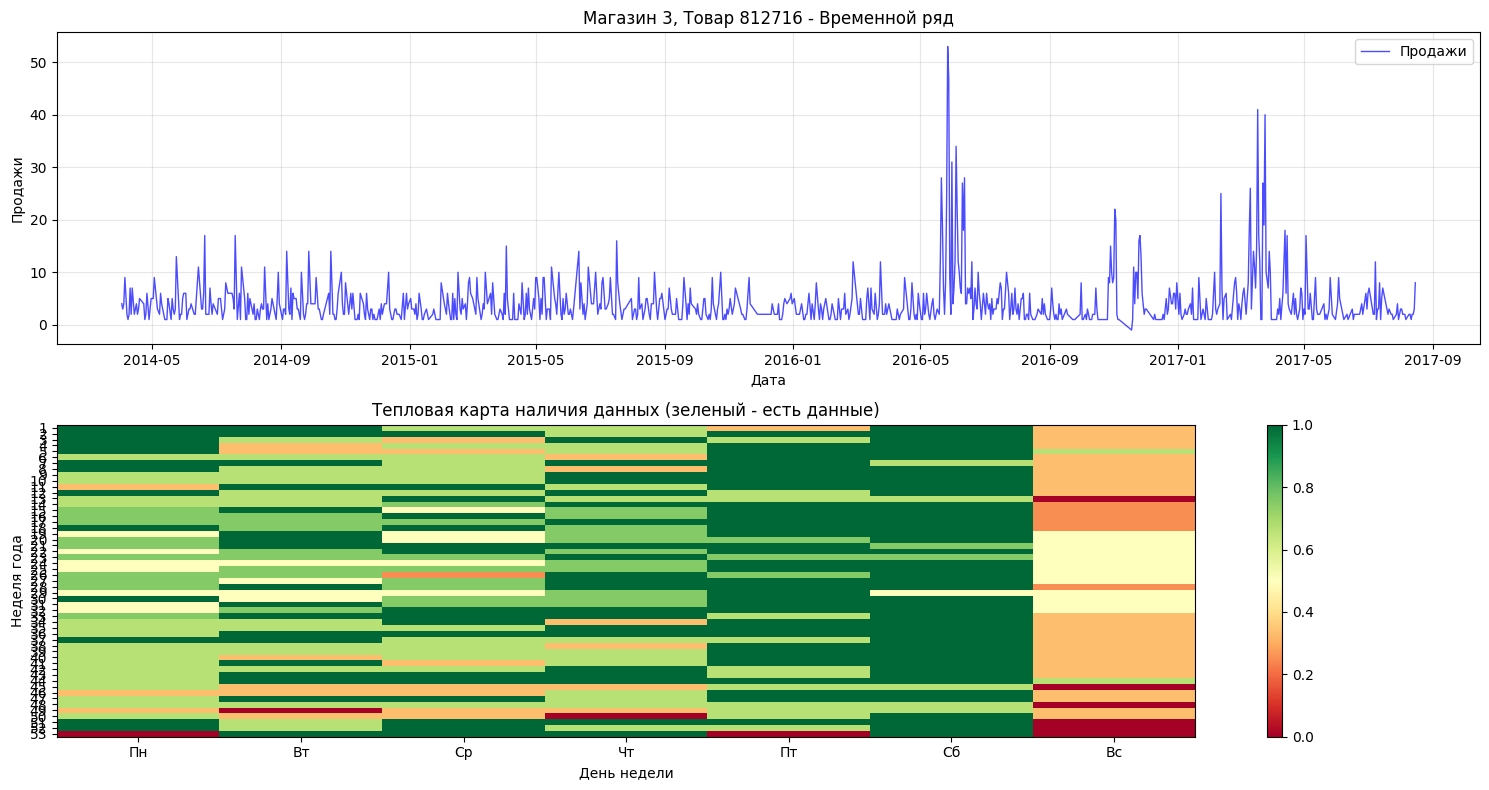


Пара: магазин 34, товар 1464065
Период: 2014-07-01 -> 2017-08-15
Всего дней в периоде: 1142
Записей в данных: 713
Пропущено дней: 429 (37.57%)
Дубликатов дат: 0
Примеры пропущенных дат (последние 10): [datetime.date(2017, 5, 17), datetime.date(2017, 6, 6), datetime.date(2017, 6, 7), datetime.date(2017, 6, 17), datetime.date(2017, 7, 1), datetime.date(2017, 7, 12), datetime.date(2017, 7, 15), datetime.date(2017, 7, 22), datetime.date(2017, 7, 31), datetime.date(2017, 8, 13)]

Проверка наличия нулевых продаж:
  Записей с нулевыми продажами: 0


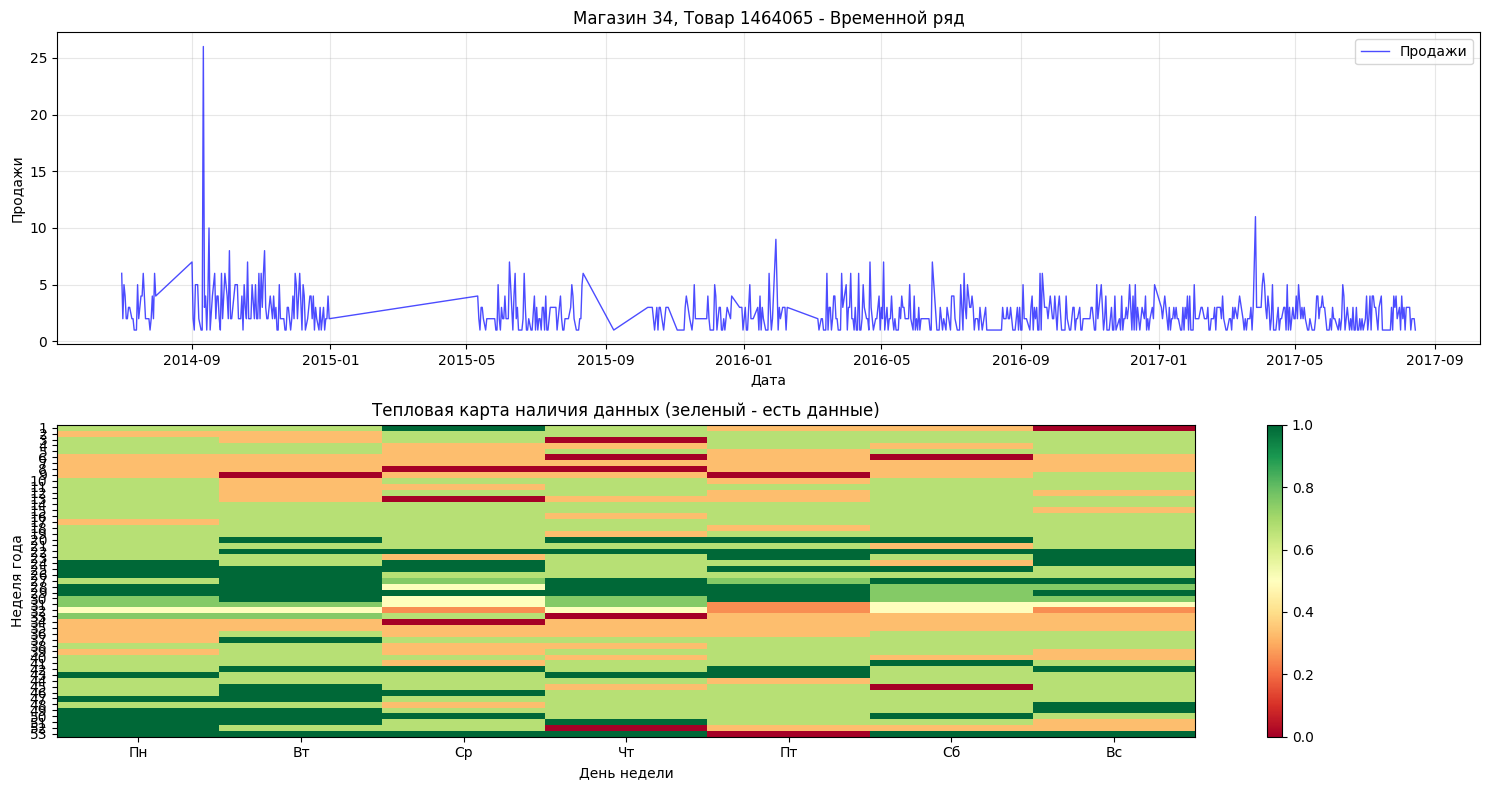


Пара: магазин 19, товар 1012787
Период: 2014-04-01 -> 2017-08-15
Всего дней в периоде: 1233
Записей в данных: 892
Пропущено дней: 341 (27.66%)
Дубликатов дат: 0
Примеры пропущенных дат (последние 10): [datetime.date(2017, 6, 27), datetime.date(2017, 6, 28), datetime.date(2017, 6, 29), datetime.date(2017, 7, 10), datetime.date(2017, 7, 18), datetime.date(2017, 7, 20), datetime.date(2017, 7, 22), datetime.date(2017, 7, 26), datetime.date(2017, 7, 27), datetime.date(2017, 8, 12)]

Проверка наличия нулевых продаж:
  Записей с нулевыми продажами: 0


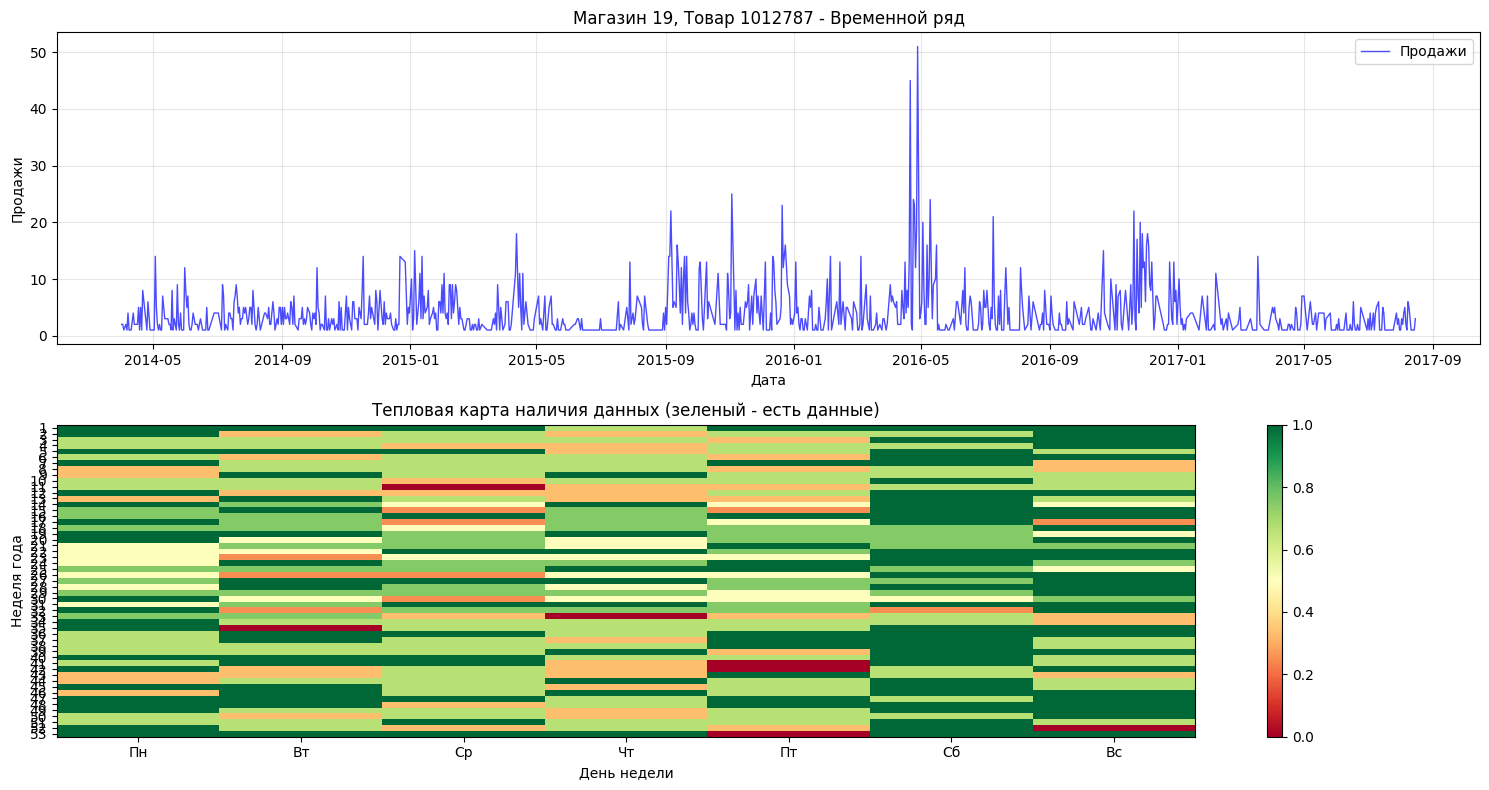

In [15]:
random_check = check_random_pairs(train, n_pairs=3)

Действительно, к сожалению, пропуски встречаются там и тут :D  
Для моделей это плохо, особенно в контексте учета сезонностей.  

Я заполняю только последние 3 месяца данных, потому что датасет огромный и полное заполнение занимает слишком много времени. В прочем, гипотетически сделать это можно и нужно, но для учебного проекта я предпочту более простые решения.

In [16]:
# train_filled_last3m = fill_missing_dates_recent(train)

In [17]:
# train.to_parquet(
#     "../data/prepared_data/train_filled_last3m.parquet",
#     engine="fastparquet",
#     compression="snappy",
#     index=False,
# )

## Сохранение подготовленного датасета

Сохраним подготовленный датасет для будщего использования.

In [ ]:
# train.to_parquet(
    # "../data/prepared_data/train_optimized.parquet",
    # engine="fastparquet",
    # compression="snappy",
    # index=False,
# )

## Основные статистики и распределения

In [19]:
print(f"Период данных: с {train['date'].min()} по {train['date'].max()}")
print(f"Количество дней: {(train['date'].max() - train['date'].min()).days}")
print(f"Уникальных магазинов: {train['store_nbr'].nunique()}")
print(f"Уникальных товаров: {train['item_nbr'].nunique()}")

Период данных: с 2014-04-01 00:00:00 по 2017-08-15 00:00:00
Количество дней: 1232
Уникальных магазинов: 54
Уникальных товаров: 4036


In [20]:
sales_stats = train["unit_sales"].describe(
    [0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]
)
print("Статистика продаж")
sales_stats

Статистика продаж


count    1.038394e+08
mean     8.492706e+00
std      2.430697e+01
min     -1.537200e+04
1%       1.000000e+00
5%       1.000000e+00
10%      1.000000e+00
25%      2.000000e+00
50%      4.000000e+00
75%      9.000000e+00
90%      1.800000e+01
95%      2.900000e+01
99%      7.100000e+01
max      8.944000e+04
Name: unit_sales, dtype: float64

In [21]:
returns_pct = (train["unit_sales"] < 0).mean() * 100
print(f"Доля возвратов: {returns_pct:.4f}%")

Доля возвратов: 0.0062%


In [22]:
promo_pct = (train["onpromotion"] == 1).mean() * 100
print(f"Доля промо: {promo_pct:.2f}%")

Доля промо: 7.52%


Для оформления графиков использую DEEPSEEK.

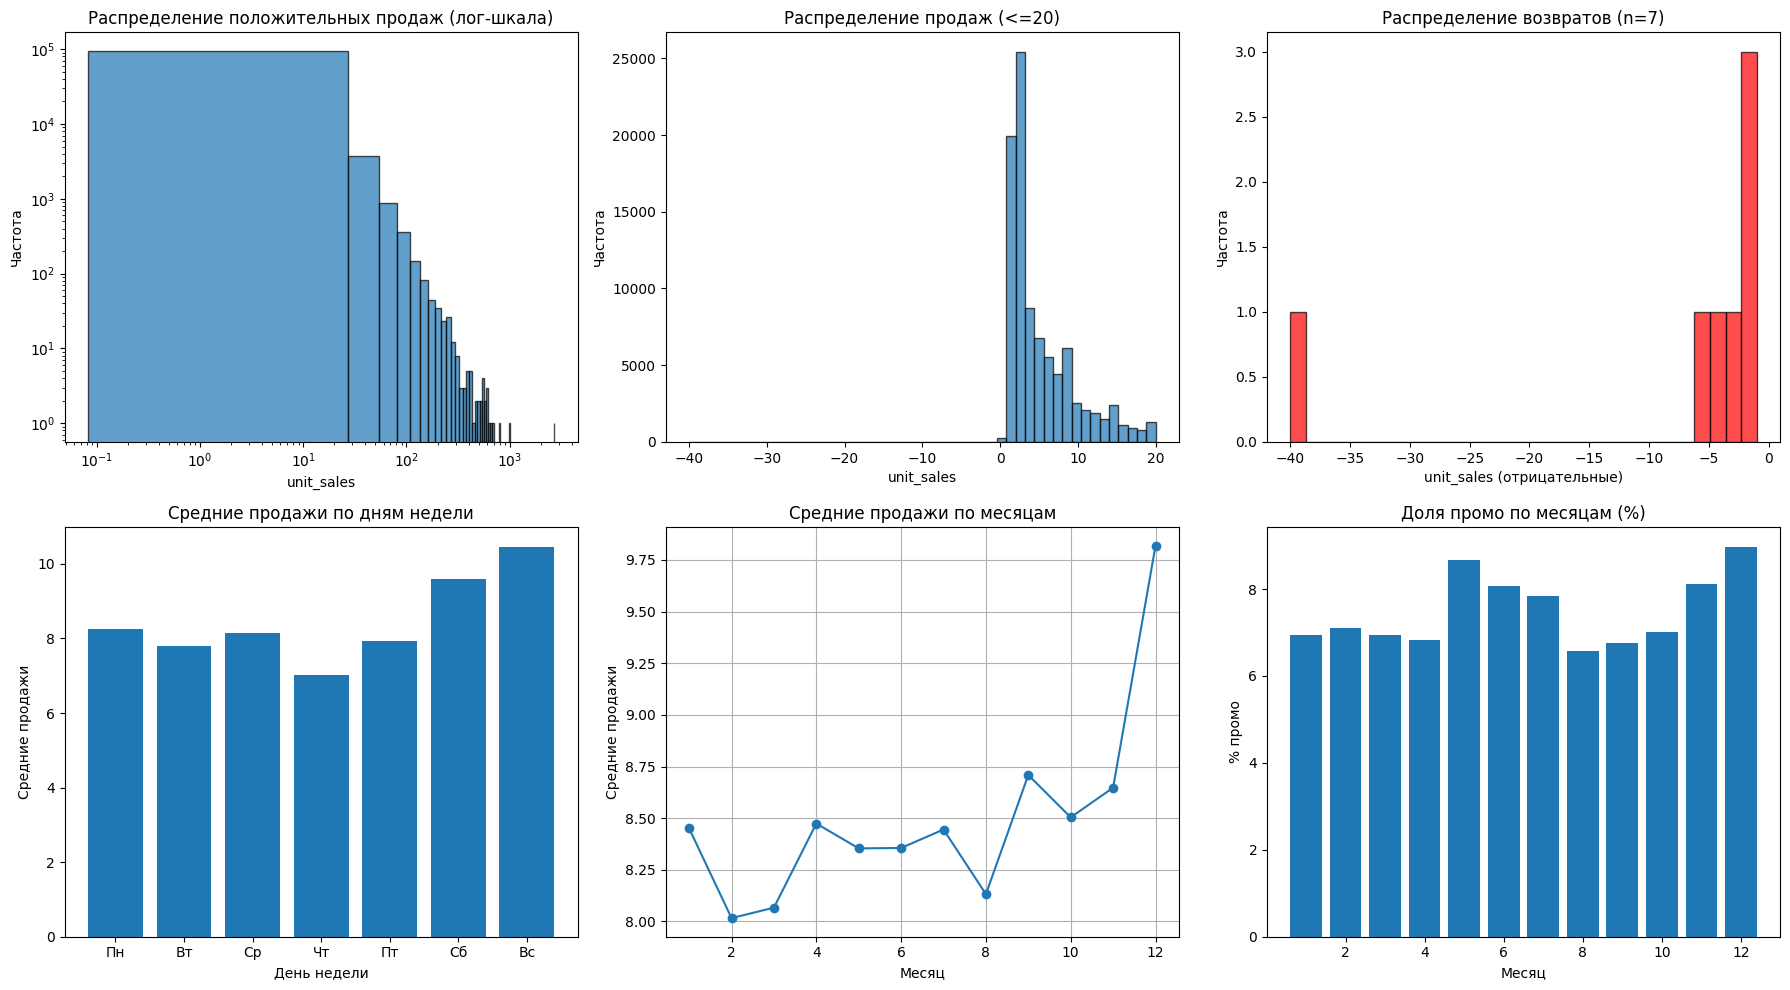

In [23]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Распределение продаж (с ограничением для наглядности)
sales_sample = train["unit_sales"].sample(100000)
sales_sample_pos = sales_sample[sales_sample > 0]

axes[0, 0].hist(sales_sample_pos, bins=100, edgecolor="black", alpha=0.7)
axes[0, 0].set_title("Распределение положительных продаж (лог-шкала)")
axes[0, 0].set_xlabel("unit_sales")
axes[0, 0].set_ylabel("Частота")
axes[0, 0].set_yscale("log")
axes[0, 0].set_xscale("log")

# Распределение продаж (ближний план)
axes[0, 1].hist(sales_sample[sales_sample <= 20], bins=50, edgecolor="black", alpha=0.7)
axes[0, 1].set_title("Распределение продаж (<=20)")
axes[0, 1].set_xlabel("unit_sales")
axes[0, 1].set_ylabel("Частота")

# Возвраты
returns_sample = sales_sample[sales_sample < 0]
if len(returns_sample) > 0:
    axes[0, 2].hist(returns_sample, bins=30, edgecolor="black", alpha=0.7, color="red")
    axes[0, 2].set_title(f"Распределение возвратов (n={len(returns_sample)})")
    axes[0, 2].set_xlabel("unit_sales (отрицательные)")
    axes[0, 2].set_ylabel("Частота")

# Продажи по дням недели
train["day_of_week"] = train["date"].dt.dayofweek
day_names = ["Пн", "Вт", "Ср", "Чт", "Пт", "Сб", "Вс"]
dow_sales = train.groupby("day_of_week")["unit_sales"].mean()
axes[1, 0].bar(day_names, dow_sales.values)
axes[1, 0].set_title("Средние продажи по дням недели")
axes[1, 0].set_xlabel("День недели")
axes[1, 0].set_ylabel("Средние продажи")

# Продажи по месяцам
train["month"] = train["date"].dt.month
month_sales = train.groupby("month")["unit_sales"].mean()
axes[1, 1].plot(month_sales.index, month_sales.values, marker="o")
axes[1, 1].set_title("Средние продажи по месяцам")
axes[1, 1].set_xlabel("Месяц")
axes[1, 1].set_ylabel("Средние продажи")
axes[1, 1].grid(True)

# Доля промо по месяцам
promo_by_month = train.groupby("month")["onpromotion"].mean() * 100
axes[1, 2].bar(promo_by_month.index, promo_by_month.values)
axes[1, 2].set_title("Доля промо по месяцам (%)")
axes[1, 2].set_xlabel("Месяц")
axes[1, 2].set_ylabel("% промо")

plt.tight_layout()
plt.show()

Из статистик и графиков можно сделать следующие выводы:
1. Большинство продаж - достаточно небольшие (количество единиц товара за продажу). Медиана - 4 единицы. Однако на высоких квартилях значения продаж достаточно большие. По условиям задачи - мы работаем с очень разными типами продукции, в том числе есть как штучные продукты, так и весовые (с нецелым значением проданных единиц), из этого факта может исходить то, что средние (график средних продаж по месяцам) практически в 2 раза выше медиан.
2. По выходным продажи несколько более активны, но очень заметного преобладания нет
3. Продажи достаточно резко взлетают в конце года и особенно в декабре
4. Наибольшее количество акций приходится на май и декабрь (но разрыв не очень существенный)

## Анализ временного ряда

In [24]:
daily_sales = (
    train.groupby("date")["unit_sales"].agg(["sum", "mean", "count"]).reset_index()
)
daily_sales.columns = ["date", "total_sales", "avg_sales", "num_transactions"]
daily_sales = daily_sales.sort_values("date")

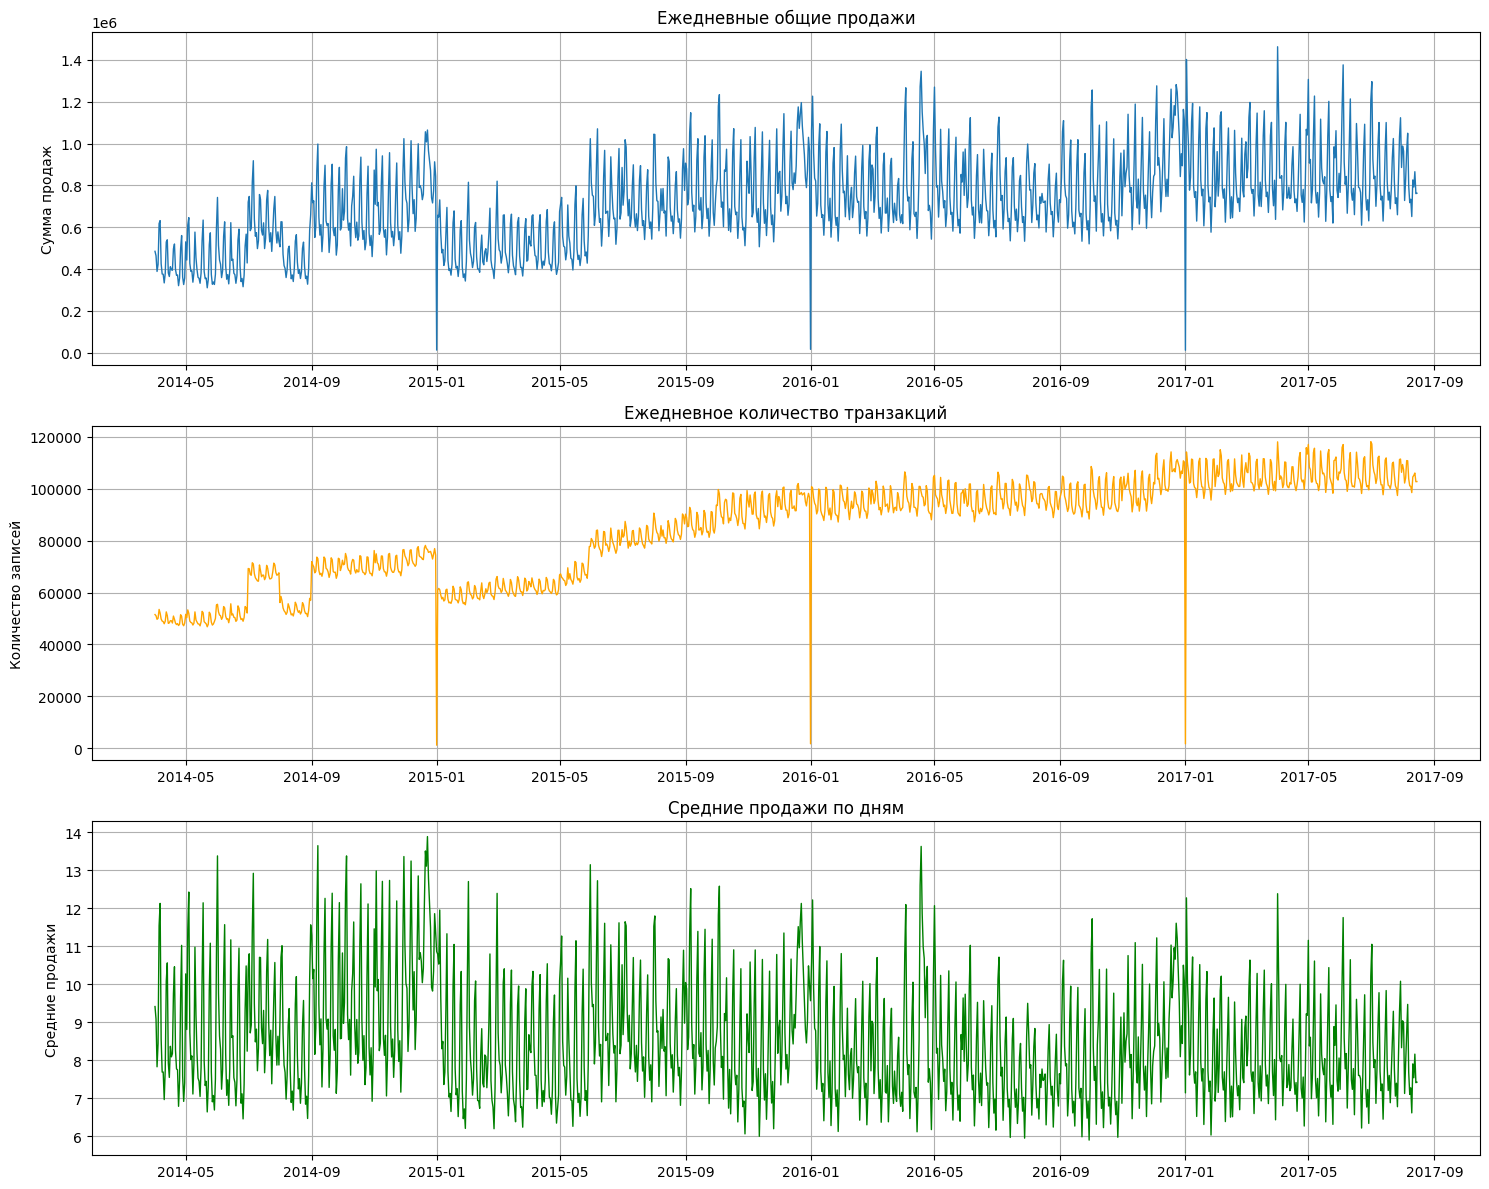

In [25]:
fig, axes = plt.subplots(3, 1, figsize=(15, 12))

# Общие продажи по дням
axes[0].plot(daily_sales["date"], daily_sales["total_sales"], linewidth=1)
axes[0].set_title("Ежедневные общие продажи")
axes[0].set_ylabel("Сумма продаж")
axes[0].grid(True)

# Количество транзакций по дням
axes[1].plot(
    daily_sales["date"], daily_sales["num_transactions"], linewidth=1, color="orange"
)
axes[1].set_title("Ежедневное количество транзакций")
axes[1].set_ylabel("Количество записей")
axes[1].grid(True)

# Средние продажи по дням
axes[2].plot(daily_sales["date"], daily_sales["avg_sales"], linewidth=1, color="green")
axes[2].set_title("Средние продажи по дням")
axes[2].set_ylabel("Средние продажи")
axes[2].grid(True)

plt.tight_layout()
plt.show()

Очень бросаются в глаза резкие выбросы в районе Нового Года (около 1 янврая) - большинство магазинов в этот день не работают и продажи резко сокращаются. Однако в ноль они не обращаются, что видно на графике средних продаж.

Тренды на графиках выделить достаточно сложно. Можно притянуть и сказать, что небольшие тренды есть, но все же выделить что-то такое можно только для первого года. Средние на бОльших частях графиков все же примерно равны.  
Точно можно увидеть сезонность. Колебания в масштабах всего ряда достаточно резкие - можно предположить, что сезонность тут есть недельная, но для точного определения проведем дополнительный анализ.

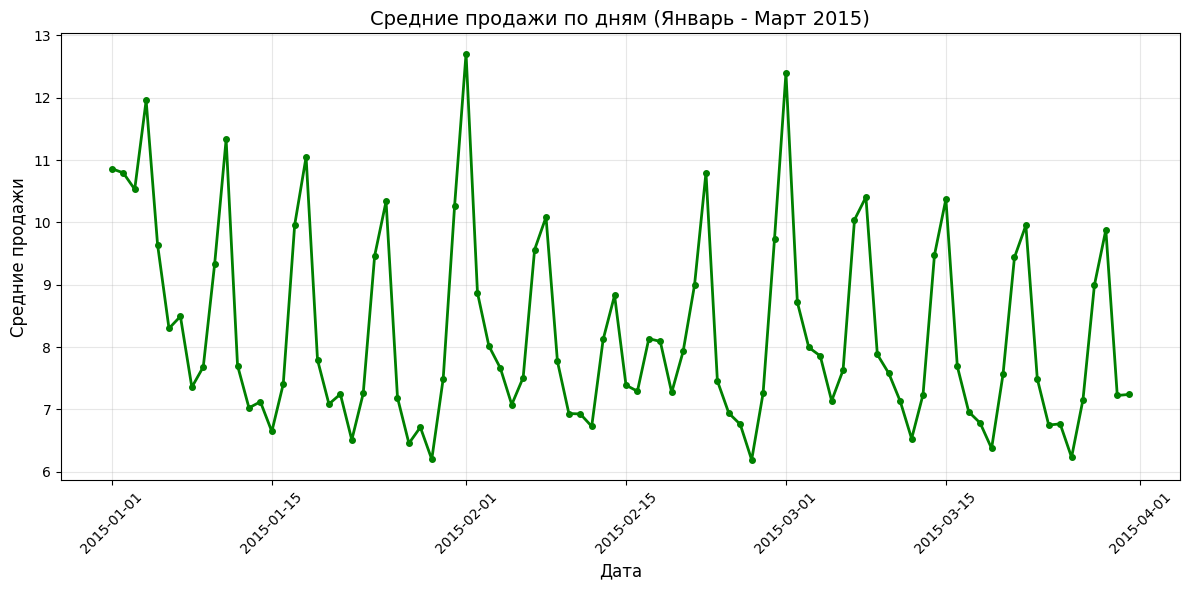

In [26]:
fig, ax = plt.subplots(figsize=(12, 6))

start_date = "2015-01-01"
end_date = "2015-03-31"

filtered_sales = daily_sales[
    (daily_sales["date"] >= start_date) & (daily_sales["date"] <= end_date)
]

ax.plot(
    filtered_sales["date"],
    filtered_sales["avg_sales"],
    linewidth=2,
    color="green",
    marker="o",
    markersize=4,
)

ax.set_title("Средние продажи по дням (Январь - Март 2015)", fontsize=14)
ax.set_ylabel("Средние продажи", fontsize=12)
ax.set_xlabel("Дата", fontsize=12)
ax.grid(True, alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Действительно, мы имеем дело с недельной сезонностью.

## Взаимосвязь продаж с промо

In [27]:
train["year_month"] = train["date"].dt.to_period("M")
monthly_stats = (
    train.groupby("year_month")
    .agg({"unit_sales": "mean", "onpromotion": "mean"})
    .round(4)
)
monthly_stats.columns = ["avg_sales", "pct_promo"]

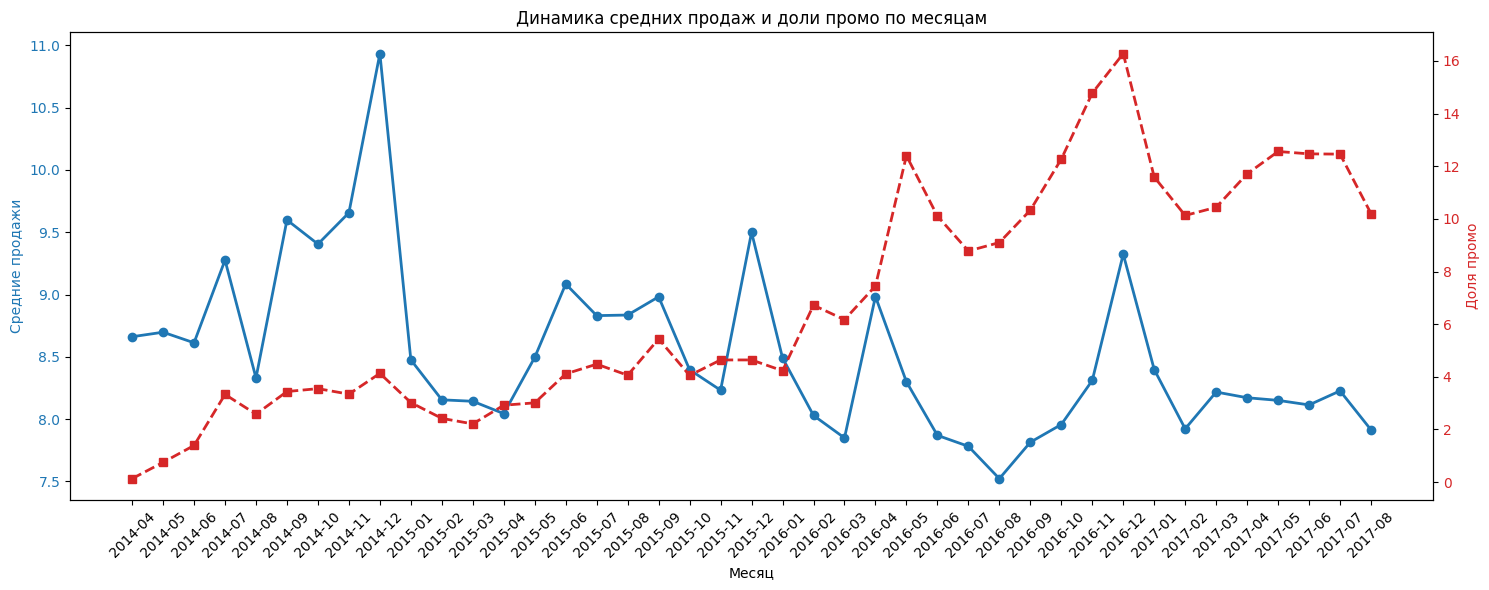

In [28]:
fig, ax1 = plt.subplots(figsize=(15, 6))

# Средние продажи
color = "tab:blue"
ax1.set_xlabel("Месяц")
ax1.set_ylabel("Средние продажи", color=color)
ax1.plot(
    monthly_stats.index.astype(str),
    monthly_stats["avg_sales"],
    marker="o",
    color=color,
    linewidth=2,
)
ax1.tick_params(axis="y", labelcolor=color)
ax1.tick_params(axis="x", rotation=45)

# Доля промо на второй оси
ax2 = ax1.twinx()
color = "tab:red"
ax2.set_ylabel("Доля промо", color=color)
ax2.plot(
    monthly_stats.index.astype(str),
    monthly_stats["pct_promo"] * 100,
    marker="s",
    color=color,
    linewidth=2,
    linestyle="--",
)
ax2.tick_params(axis="y", labelcolor=color)

plt.title("Динамика средних продаж и доли промо по месяцам")
plt.tight_layout()
plt.show()

In [29]:
train = train.drop(["year_month"], axis=1)

Очень интересная ситуация на графике - до, примерно, 2016-01 количество промо находится в диапазоне 0-5 процентов, но потом достаточно резко границы увеличиваются аж до 7-17 процентов, при том средний уровень продаж там достаточно ощутимо просел. Видимо, случилось что-то нехорошее и для повышения продаж продавец был вынужден вводить значительно большее количество промо.

## Декомпозиция временного ряда

Для анализа структуры временного ряда выберем наиболее популярную пару "магазин-товар" (с максимальным количеством дней с продажами). Это позволит нам на конкретном примере разложить ряд на составляющие: тренд, сезонность и остатки.

In [30]:
popular_pair = train.groupby(["store_nbr", "item_nbr"]).size().nlargest(1).index[0]
store, item = popular_pair
print(f"Анализируем магазин {store}, товар {item}")

Анализируем магазин 2, товар 114790


In [31]:
pair_data = train[(train["store_nbr"] == store) & (train["item_nbr"] == item)].copy()
pair_data = pair_data.set_index("date").sort_index()

full_date_range = pd.date_range(
    start=pair_data.index.min(), end=pair_data.index.max(), freq="D"
)
pair_data = pair_data.reindex(full_date_range)
pair_data["unit_sales"] = pair_data["unit_sales"].fillna(0)

In [32]:
len(pair_data)

1233

Данных получилось вполне достаточно для анализа, супер :D

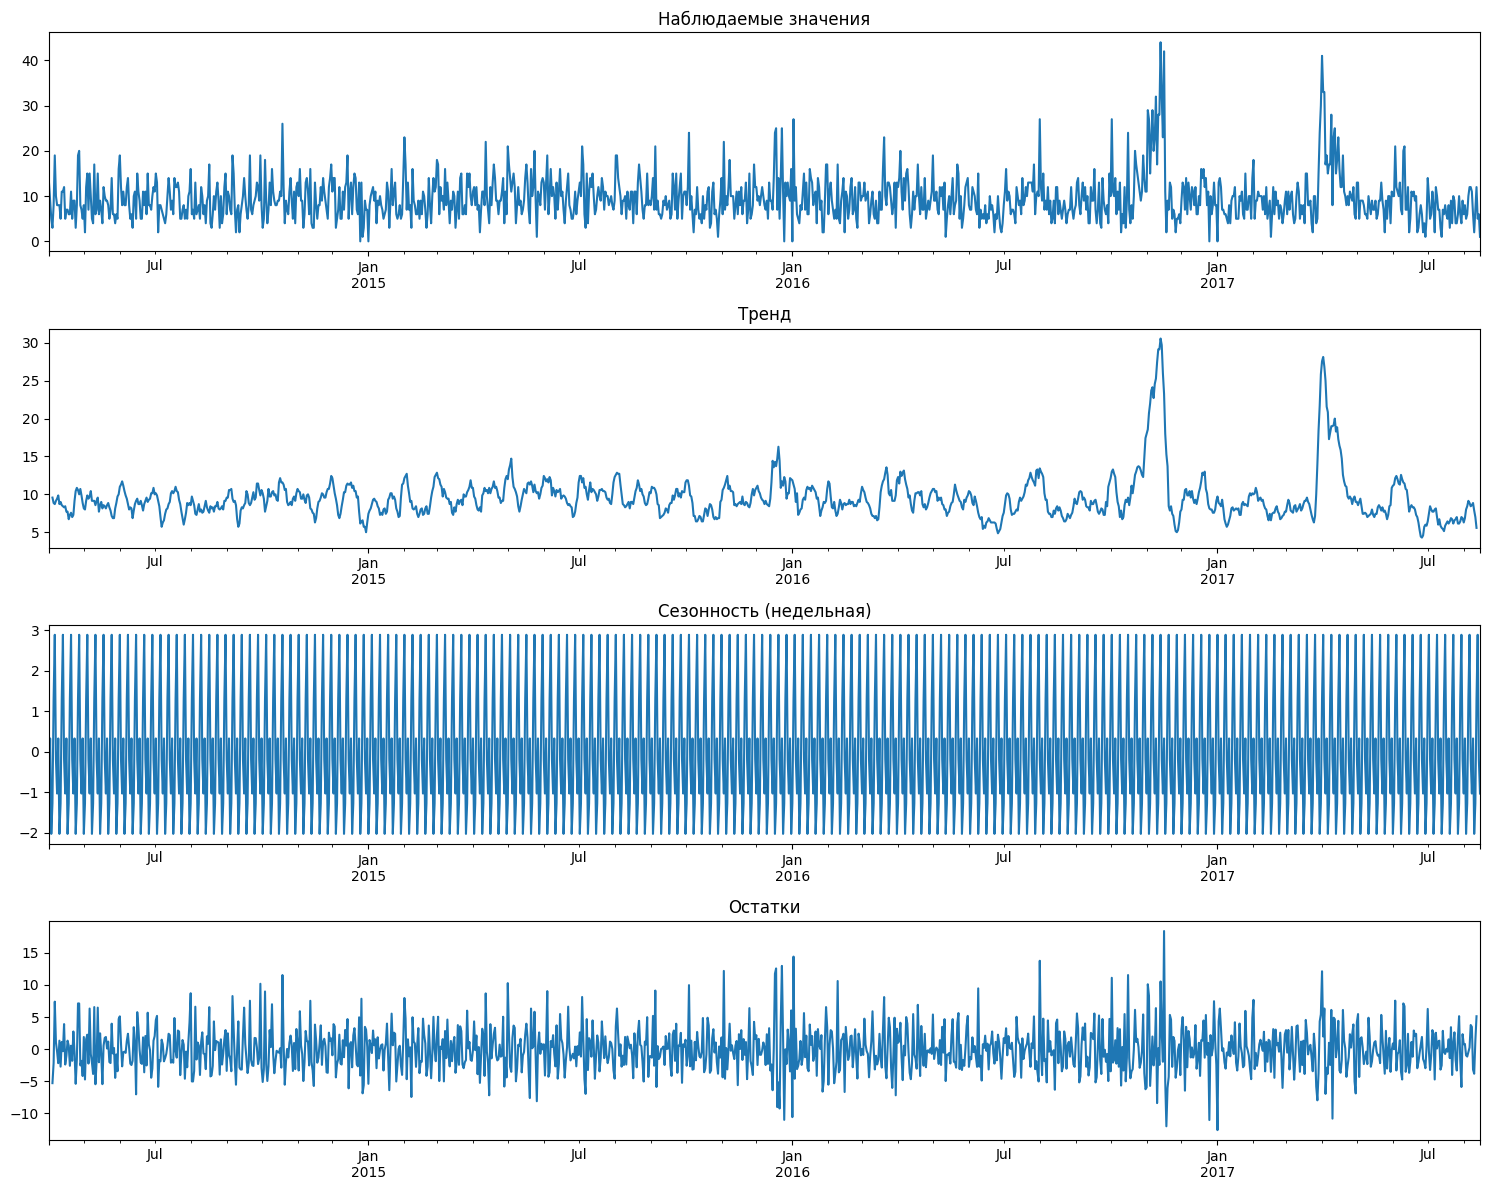

In [33]:
decomposition = seasonal_decompose(pair_data["unit_sales"], model="additive", period=7)

fig, axes = plt.subplots(4, 1, figsize=(15, 12))
decomposition.observed.plot(ax=axes[0], title="Наблюдаемые значения")
decomposition.trend.plot(ax=axes[1], title="Тренд")
decomposition.seasonal.plot(ax=axes[2], title="Сезонность (недельная)")
decomposition.resid.plot(ax=axes[3], title="Остатки")
plt.tight_layout()
plt.show()

Ситуация достаточно сложная. `Тренд`, как мы и заметили выше, `выделяется с трудом`. Есть некоторые большие всплески, но вокруг них `среднее колеблется вокруг 10 что в начале, что в конце`.
  
Зато `сезонность выглядит отлично` - уверенно и без перебоев (и без роста).

`Шумовая компонента` достаточно `большая`, что не есть приятно. При среднем значении ряда около 10, `шумовая компонента` гуляет `в диапазоне +- 5`. Это много. Скорее всего, при прогнозировании придется хорошо повозиться.

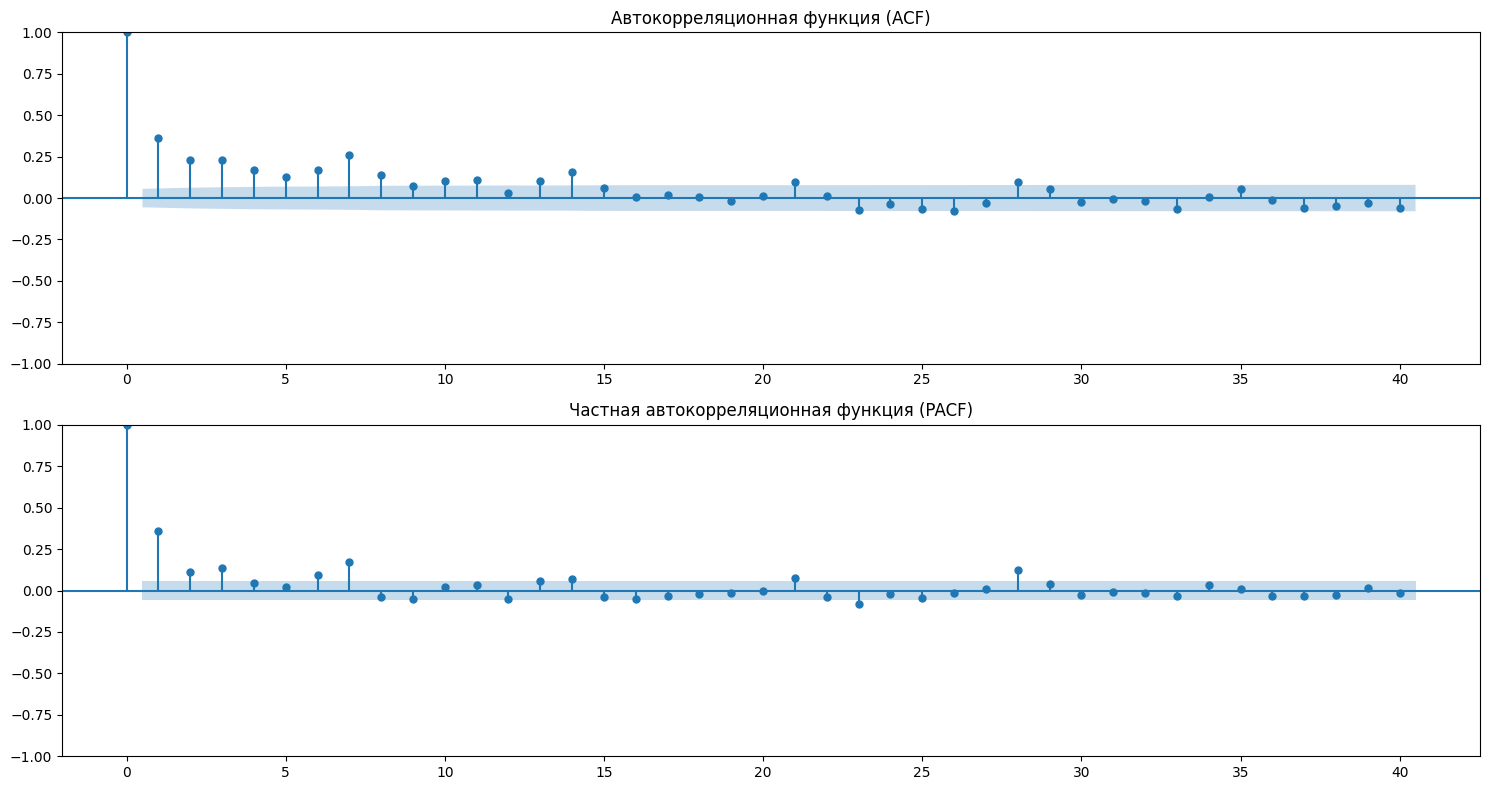

In [34]:
# Для того же товара посмотрим автокорреляцию
fig, axes = plt.subplots(2, 1, figsize=(15, 8))

# ACF
plot_acf(pair_data["unit_sales"].dropna(), lags=40, ax=axes[0])
axes[0].set_title("Автокорреляционная функция (ACF)")

# PACF
plot_pacf(pair_data["unit_sales"].dropna(), lags=40, ax=axes[1])
axes[1].set_title("Частная автокорреляционная функция (PACF)")

plt.tight_layout()
plt.show()

Автокорреляция ещё раз подтверждает наш вывод о недельной сезонности. У PACF ситуация достаточно интересная - обрыв не резкий, первые 2 лага имеют достаточно немаленькие значения (примерно 0.4 и 0.15 соответственно).

# Summary по EDA

### 1. Структура и качество данных
- **Объем**: 125 млн записей о продажах с 2013 по 2017 год
- **Память**: после оптимизации типов удалось сократить использование памяти до 1.78 GB
- **Пропуски**: выявлена системная проблема в колонке `onpromotion` — 100% пропусков в первые 15 месяцев (до апреля 2014). Принято решение удалить этот период, чтобы избежать неоднородности данных.

### 2. Целевая переменная (unit_sales)
- **Распределение**: достаточно сильно скошено, медиана = 4, среднее = 8.5
- **Возвраты**: составляют ~0.5% от всех записей
- **Тип данных**: присутствуют как целые (штучные товары), так и дробные значения (весовые товары)

### 3. Временная структура
- **Сезонность**: ярко выраженная недельная сезонность (подтверждена ACF/PACF и декомпозицией)
- **Годовая цикличность**: пик продаж в декабре (предновогодний сезон)
- **Дни недели**: продажи в выходные немного выше, но разрыв не критический
- **Аномалии**: резкие провалы 1 января (закрытие магазинов), всплеск в апреле 2016 (землетрясение)

### 4. Промо-акции
- **Динамика**: доля промо резко выросла с ~3% до ~12% после января 2016
- **Связь с продажами**: рост промо совпал с падением средних продаж (возможно, реакция на ухудшение экономической ситуации)
- **Сезонность промо**: пики в мае и декабре

### 5. Качество ряда для прогнозирования
- **Сигнал/шум**: отношение ~2 (среднее 10, шум +-5) — ряд очень шумный
- **Стационарность**: тренд слабо выражен, ряд колеблется вокруг относительно стабильного среднего
- **Прогнозируемость**: высокая сезонность помогает, но высокий уровень шума потребует сложных моделей

# EDA по другим датафреймам

Посмотрим, что есть в других датафреймах. Поскольку нам придется использовать хотя бы часть экзогеннх признаков, стоит посмотреть, что вообще есть в других датасетах. Не ради глубокого анализа, а просто для общего понимания ситуации.

## Функция обработки датасетов

In [35]:
def cut_save_df(df, name):
    df = df[df["date"] >= "2014-04-01"].copy()
    df, _ = reduce_mem_usage(df)
    df.to_parquet(
        f"../data/prepared_data/{name}_optimized.parquet",
        engine="fastparquet",
        compression="snappy",
        index=False,
    )

## Тестовые данные (test)

In [36]:
test = pd.read_csv(os.path.join(DATA_DIR, "test.csv"), parse_dates=["date"]).set_index(
    "id"
)
test["onpromotion"] = test["onpromotion"].astype(int)

In [37]:
print(test.shape)
test.head()

(3370464, 4)


,date,store_nbr,item_nbr,onpromotion
id,,,,
125497040,2017-08-16,1,96995,0
125497041,2017-08-16,1,99197,0
125497042,2017-08-16,1,103501,0
125497043,2017-08-16,1,103520,0
125497044,2017-08-16,1,103665,0


In [38]:
print(f"Период: с {test['date'].min()} по {test['date'].max()}")

Период: с 2017-08-16 00:00:00 по 2017-08-31 00:00:00


Несмотря на несколько лет тренировочных данных, весь тест - две недели. Стоит иметь это в виду.

In [39]:
cut_save_df(test, "test")

Начальное использование памяти: 115.72 MB


Оптимизация колонок: 100%|██████████| 4/4 [00:00<00:00, 129.14it/s]

Конечное использование памяти: 70.72 MB
Сокращение памяти: 38.9%


## Информация о магазинах (stores)

In [40]:
stores = pd.read_csv(os.path.join(DATA_DIR, "stores.csv"))

In [41]:
print(stores.shape)
stores.head()

(54, 5)


,store_nbr,city,state,type,cluster
0,1,Quito,Pichincha,D,13
1,2,Quito,Pichincha,D,13
2,3,Quito,Pichincha,D,8
3,4,Quito,Pichincha,D,9
4,5,Santo Domingo,Santo Domingo de los Tsachilas,D,4


In [42]:
print("Распределение по кластерам:")
print(stores["cluster"].value_counts())

Распределение по кластерам:
cluster
3     7
6     6
10    6
15    5
13    4
14    4
11    3
4     3
8     3
1     3
9     2
7     2
2     2
12    1
5     1
16    1
17    1
Name: count, dtype: int64


In [43]:
print("Распределение по типам:")
print(stores["type"].value_counts())

Распределение по типам:
type
D    18
C    15
A     9
B     8
E     4
Name: count, dtype: int64


In [44]:
print("Города:")
print(stores["city"].value_counts())

Города:
city
Quito            18
Guayaquil         8
Cuenca            3
Santo Domingo     3
Manta             2
Latacunga         2
Machala           2
Ambato            2
Quevedo           1
Esmeraldas        1
Loja              1
Libertad          1
Playas            1
Daule             1
Babahoyo          1
Salinas           1
Puyo              1
Guaranda          1
Ibarra            1
Riobamba          1
Cayambe           1
El Carmen         1
Name: count, dtype: int64


## Информация о товарах (items)

In [45]:
items = pd.read_csv(os.path.join(DATA_DIR, "items.csv"))

In [46]:
print(items.shape)
items.head()

(4100, 4)


,item_nbr,family,class,perishable
0,96995,GROCERY I,1093,0
1,99197,GROCERY I,1067,0
2,103501,CLEANING,3008,0
3,103520,GROCERY I,1028,0
4,103665,BREAD/BAKERY,2712,1


In [47]:
print(f"Распределение по семействам (всего классов - {items['family'].nunique()}):")
print(items["family"].value_counts().head(10))

Распределение по семействам (всего классов - 33):
family
GROCERY I        1334
BEVERAGES         613
CLEANING          446
PRODUCE           306
DAIRY             242
PERSONAL CARE     153
BREAD/BAKERY      134
HOME CARE         108
DELI               91
MEATS              84
Name: count, dtype: int64


In [48]:
print("Доля скоропортящихся товаров:")
print(items["perishable"].value_counts(normalize=True))

Доля скоропортящихся товаров:
perishable
0    0.759512
1    0.240488
Name: proportion, dtype: float64


За скоропортящиеся товары повышенный штраф, по условиям задачи на kaggle.

## Транзакции (transactions)

In [49]:
transactions = pd.read_csv(
    os.path.join(DATA_DIR, "transactions.csv"), parse_dates=["date"]
)

In [50]:
print(transactions.shape)
transactions.head()

(83488, 3)


,date,store_nbr,transactions
0,2013-01-01,25,770
1,2013-01-02,1,2111
2,2013-01-02,2,2358
3,2013-01-02,3,3487
4,2013-01-02,4,1922


In [51]:
train_stores = train["store_nbr"].unique()
trans_stores = transactions["store_nbr"].unique()
print(f"Магазины, которых нет в transactions: {set(train_stores) - set(trans_stores)}")

Магазины, которых нет в transactions: set()


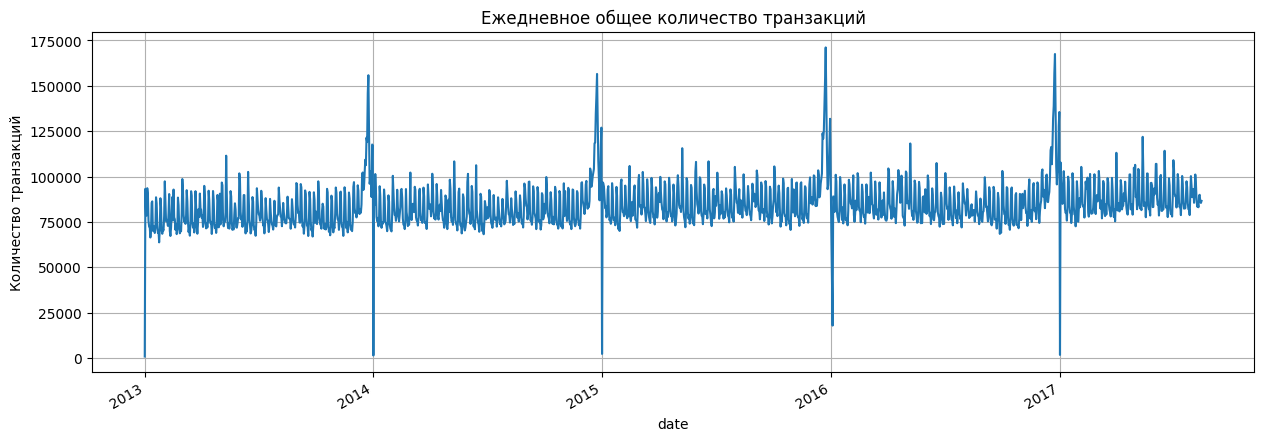

In [52]:
daily_trans = transactions.groupby("date")["transactions"].sum()
plt.figure(figsize=(15, 5))
daily_trans.plot()
plt.title("Ежедневное общее количество транзакций")
plt.ylabel("Количество транзакций")
plt.grid(True)
plt.show()

In [53]:
cut_save_df(transactions, "transactions")

Начальное использование памяти: 1.90 MB


Оптимизация колонок: 100%|██████████| 3/3 [00:00<?, ?it/s]

Конечное использование памяти: 1.13 MB
Сокращение памяти: 40.6%


## Цены на нефть (oil)

In [54]:
oil = pd.read_csv(os.path.join(DATA_DIR, "oil.csv"), parse_dates=["date"])

In [55]:
print(oil.shape)
oil.head()

(1218, 2)


,date,dcoilwtico
0,2013-01-01,NaN
1,2013-01-02,93.14
2,2013-01-03,92.97
3,2013-01-04,93.12
4,2013-01-07,93.20


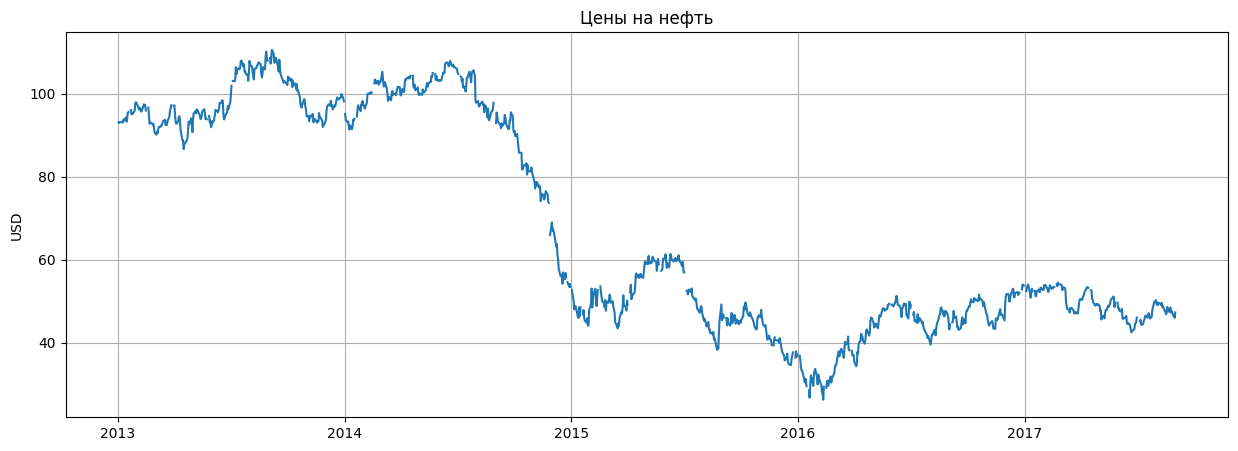

In [56]:
plt.figure(figsize=(15, 5))
plt.plot(oil["date"], oil["dcoilwtico"])
plt.title("Цены на нефть")
plt.ylabel("USD")
plt.grid(True)
plt.show()

Цены на нефть достаточно сильно упали около нового года 2016, возможно, именно это повлияло на картину, которую мы видели с упавшим в этот период количеством продаж.

In [57]:
cut_save_df(oil, "oil")

Начальное использование памяти: 0.02 MB


Оптимизация колонок: 100%|██████████| 2/2 [00:00<00:00, 24.18it/s]

Конечное использование памяти: 0.02 MB
Сокращение памяти: 16.7%


## Праздники (holidays_events)

In [58]:
holidays = pd.read_csv(
    os.path.join(DATA_DIR, "holidays_events.csv"), parse_dates=["date"]
)

In [59]:
print(holidays.shape)
holidays.head()

(350, 6)


,date,type,locale,locale_name,description,transferred
0,2012-03-02,Holiday,Local,Manta,Fundacion de Manta,False
1,2012-04-01,Holiday,Regional,Cotopaxi,Provincializacion de Cotopaxi,False
2,2012-04-12,Holiday,Local,Cuenca,Fundacion de Cuenca,False
3,2012-04-14,Holiday,Local,Libertad,Cantonizacion de Libertad,False
4,2012-04-21,Holiday,Local,Riobamba,Cantonizacion de Riobamba,False


In [60]:
print("Типы событий:")
print(holidays["type"].value_counts())

Типы событий:
type
Holiday       221
Event          56
Additional     51
Transfer       12
Bridge          5
Work Day        5
Name: count, dtype: int64


In [61]:
print("Распределение по transferred:")
print(holidays["transferred"].value_counts())

Распределение по transferred:
transferred
False    338
True      12
Name: count, dtype: int64


Данные слишком специфичны и их мало. Самым оптимальным решением относительного этого датасета выглядит - просто им пренебречь. 